In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
dia = pd.read_csv("diamonds.csv")

In [4]:
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
dia.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [6]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [7]:
dia.shape

(53940, 10)

In [8]:
dia.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [9]:
dia.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [10]:
print((dia[['x','y','z']] == 0).sum())

x     8
y     7
z    20
dtype: int64


In [11]:
for col in ['cut','color','clarity']:
    if col in dia.columns:
        print(f"\n Unique values in {col}:")
        print(dia[col].value_counts(dropna=False))


 Unique values in cut:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

 Unique values in color:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

 Unique values in clarity:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [12]:
dia[['x','y','z']] = dia[['x','y','z']].replace(0,np.NaN)

In [13]:
print("Missing values after replacing zeros:")
print(dia.isna().sum())

Missing values after replacing zeros:
carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           8
y           7
z          20
dtype: int64


In [14]:
dia[['x','y','z']] = dia[['x','y','z']].fillna(dia[['x','y','z']].median())

In [15]:
print("After filling with median:")
print(dia.isna().sum())

After filling with median:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [16]:
num_cols = dia.select_dtypes(include=np.number).columns

In [17]:
num_cols

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')

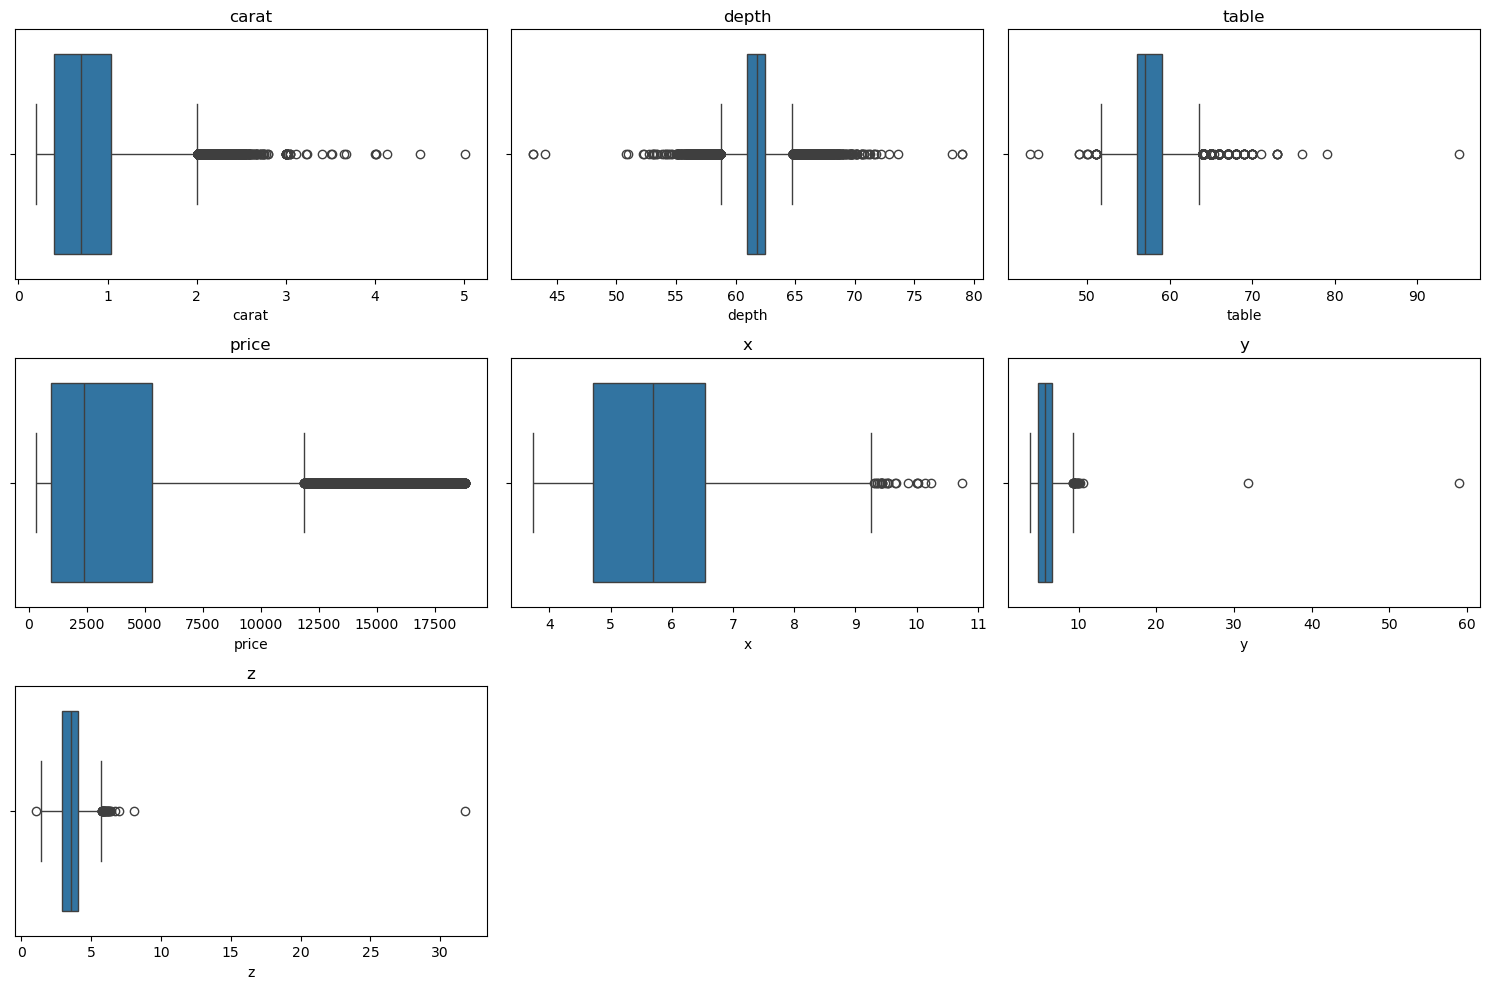

In [18]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=dia[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [19]:
dia[['x','y','z']].describe()

,x,y,z
count,53940.000000,53940.000000,53940.000000
mean,5.732003,5.735267,3.540043
std,1.119587,1.140265,0.702400
min,3.730000,3.680000,1.070000
25%,4.710000,4.720000,2.910000
50%,5.700000,5.710000,3.530000
75%,6.540000,6.540000,4.040000
max,10.740000,58.900000,31.800000


In [20]:
dia = dia[(dia['x'] > 0) & (dia['y'] > 0) & (dia['z'] > 0)]
dia

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [21]:
dia = dia[(dia['y'] < 30) & (dia['z'] < 20)]
dia

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [22]:
dia.shape

(53937, 10)

In [23]:
filtered_values = dia[['x', 'y', 'z']][(dia['x'] > 20) | (dia['y'] > 20) | (dia['z'] > 20)]

In [24]:
filtered_values.sum()

x    0.0
y    0.0
z    0.0
dtype: float64

# Encoding

In [25]:
cut_mapping = {'Ideal': 5,'Premium': 4,'Very Good': 3,'Good': 2,'Fair': 1}

In [26]:
color_mapping = {'D': 7,'E': 6,'F': 5,'G': 4,'H': 3,'I': 2,'J': 1}

In [27]:
clarity_mapping = {'IF': 8,'VVS1': 7,'VVS2': 6,'VS1': 5,'VS2': 4,'SI1': 3,'SI2': 2,'I1': 1}

In [28]:
dia['cut'] = dia['cut'].map(cut_mapping)
dia['color'] = dia['color'].map(color_mapping)
dia['clarity'] = dia['clarity'].map(clarity_mapping)

In [29]:
dia[['cut','color','clarity']].head()

,cut,color,clarity
0,5,6,2
1,4,6,3
2,2,6,5
3,4,2,4
4,2,1,2


In [30]:
dia.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [31]:
scaled_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']

In [32]:
scaler = StandardScaler()

dia_scaled = dia.copy()

In [34]:
dia_scaled[scaled_cols] = scaler.fit_transform(dia_scaled[scaled_cols])
dia_scaled.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.198190,0.981466,0.937177,-1.245208,-0.174129,-1.099717,326,-1.591686,-1.577996,-1.604380
1,-1.240385,0.085893,0.937177,-0.638092,-1.360786,1.585478,326,-1.645278,-1.703961,-1.777920
2,-1.198190,-1.705253,0.937177,0.576139,-3.385084,3.375608,327,-1.502365,-1.497018,-1.777920
3,-1.071604,0.085893,-1.414245,-0.030977,0.454102,0.242881,334,-1.368383,-1.353058,-1.315148
4,-1.029409,-1.705253,-2.002101,-1.245208,1.082332,0.242881,335,-1.243333,-1.245087,-1.141608


In [35]:
X = dia.drop('price', axis=1)
y = dia['price'] 

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_train.shape, X_test.shape

((43149, 9), (10788, 9))

In [38]:
X_train_scaled = scaler.fit_transform(X_train)

In [39]:
X_test_scaled = scaler.transform(X_test)

In [40]:
X_train.shape, X_test.shape

((43149, 9), (10788, 9))

In [41]:
X_train_scaled

array([[-0.77669924,  0.98363885, -0.82676674, ..., -0.80614288,
        -0.78672471, -0.75123647],
       [ 0.44598806, -0.81015823,  0.34908474, ...,  0.67570178,
         0.78678369,  0.49137307],
       [-0.60805272,  0.98363885,  0.93701048, ..., -0.53833963,
        -0.47202303, -0.53450225],
       ...,
       [-0.96642658,  0.98363885,  0.93701048, ..., -1.11858001,
        -1.09243492, -1.08356228],
       [ 0.21409909,  0.08674031, -2.00261823, ...,  0.35433788,
         0.26527804,  0.40467938],
       [ 0.72003866,  0.08674031,  0.34908474, ...,  0.97028536,
         0.94863026,  0.82369888]])

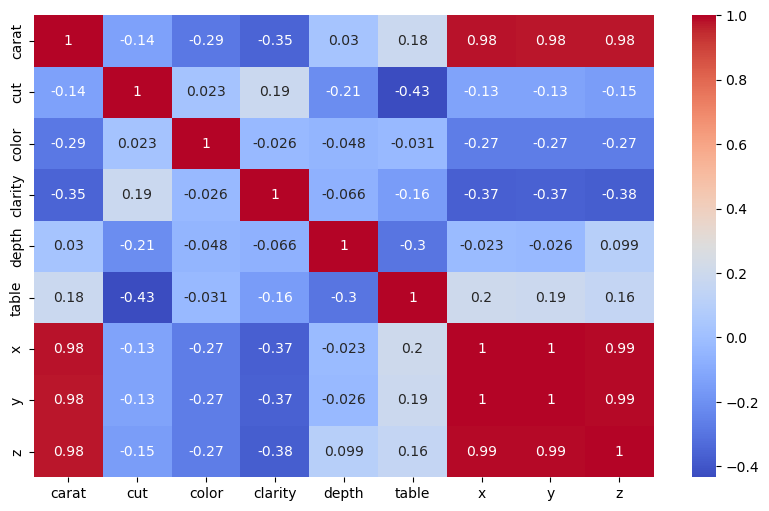

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')
plt.show()

In [43]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(len(X_train.columns))]

vif_data

,Feature,VIF
0,carat,91.706473
1,cut,17.766061
2,color,8.602480
3,clarity,8.636879
4,depth,1201.729559
5,table,850.852508
6,x,12048.059774
7,y,10446.229136
8,z,3894.688359


In [44]:
dia['volume'] = dia['x'] * dia['y'] * dia['z']

In [45]:
dia = dia.drop(columns=['x', 'y', 'z'])

In [46]:
X = dia.drop(columns=['price'])   
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data

,Feature,VIF
0,carat,1573.507256
1,cut,14.818160
2,color,8.562051
3,clarity,8.365937
4,depth,448.151424
5,table,412.979782
6,volume,1582.295774


In [47]:
dia = dia.drop(columns=['volume', 'depth', 'table'])

In [49]:
# X = dia.drop(columns=['price'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif_data

,Feature,VIF
0,carat,2.904756
1,cut,9.982441
2,color,5.563979
3,clarity,6.184388


In [50]:
X = dia.drop(columns=['price'])
y = dia['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((43149, 4), (10788, 4), (43149,), (10788,))

In [52]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [53]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

coef_df

,Feature,Coefficient
0,carat,8793.844452
1,cut,155.404327
2,color,320.233349
3,clarity,526.093944


In [54]:
y_pred = lr.predict(X_test)

In [56]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(839.8977223696215, 1199.1214435759641, 0.9074948394218454)

# Summary Of the Project:
##### - Regression model to predict diamond prices using Python, Pandas, and Scikit-Learn. 
##### - Performed complete data preprocessing (handling missing values, ordinal encoding, outlier removal, VIF-based multicollinearity treatment, feature scaling). 
##### - Developed a Linear Regression model achieving R² = 0.907, MAE = 840, and RMSE = 1199